---
# **Laboratory 8 - Exercises**

---
## Dependences

In [ ]:
# NB Update 21/12/2025 to guarantee the compatibility

!pip install causalgraphicalmodels
!pip install pyagrum

#!sed -i 's/collections/collections.abc/g' /usr/local/lib/python3.10/dist-packages/causalgraphicalmodels/cgm.py
!sed -i 's/collections/collections.abc/g' /usr/local/lib/python3.12/dist-packages/causalgraphicalmodels/cgm.py
from causalgraphicalmodels import CausalGraphicalModel

#from IPython.display import display, Math, Latex
from IPython.display import display
import pyagrum as gum
import pyagrum.lib.notebook as gnb
import pyagrum.causal as csl
import pyagrum.causal.notebook as cslnb

---
## Exercise 1

Create the following causal network to verify that the red path is indeed a backdor path using the Causal Graphical Models library between X and Y

<img src='https://drive.google.com/uc?id=18HUhYGI9Bd2eR87jW_1AdQyCZZBOtBfD'>

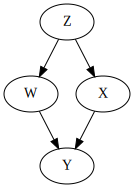

backdoor paths: [['X', 'Z', 'W', 'Y']]


In [ ]:
ex1 = CausalGraphicalModel(
    nodes=['X','Y','Z','W'],
    edges=[('X','Y'),
           ('Z','X'),
           ('Z','W'),
           ('W','Y')]
)

display(ex1.draw())
print("backdoor paths: " + str(ex1.get_all_backdoor_paths('X','Y')))

---
## Exercise 2

Create the following causal network using the Causal Graphical Models library and find out all the possible sets that satisfy the backdoor criterion between X and Y

<img src='https://drive.google.com/uc?id=1rY42DmXV7TpRm7rt5N7m78w30VmyvotC'>



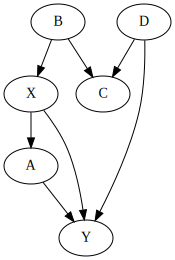

backdoor paths: [['X', 'B', 'C', 'D', 'Y']]
backdoor sets: frozenset({frozenset({'D'}), frozenset({'B', 'D'}), frozenset({'B'}), frozenset({'B', 'C', 'D'}), frozenset(), frozenset({'B', 'C'}), frozenset({'C', 'D'})})


In [ ]:
ex2 = CausalGraphicalModel(
    nodes=['X','Y','A','B','C','D'],
    edges=[('X','Y'),
           ('X','A'),
           ('A','Y'),
           ('B','X'),
           ('B','C'),
           ('D','C'),
           ('D','Y')]
)

display(ex2.draw())
print("backdoor paths: " + str(ex2.get_all_backdoor_paths('X','Y')))
print("backdoor sets: " + str(ex2.get_all_backdoor_adjustment_sets('X','Y')))

---
## Exercise 3

Create the following causal network using the Causal Graphical Models library and find out all the valid sets for applying the front-door criterion between X and Y

<img src='https://drive.google.com/uc?id=1Z6YiKMDVKPLFM5luY_pT78ovSpWH-Ibd'>


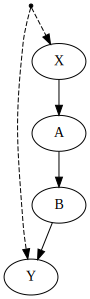

front-door sets: frozenset({frozenset({'A', 'B'}), frozenset({'B'}), frozenset({'A'})})


In [ ]:
ex3 = CausalGraphicalModel(
    nodes=['X','A','B','Y'],
    edges=[('X','A'),
           ('A','B'),
           ('B','Y')],
    latent_edges=[('X','Y')]
)

display(ex3.draw())
print("front-door sets: " + str(ex3.get_all_frontdoor_adjustment_sets('X','Y')))

---
## Exercise 4

Create the following causal network using the Causal Graphical Models library and find out all the valid sets for applying the front-door criterion between X and Y

<img src='https://drive.google.com/uc?id=1lK3HZktVYCsJrDzZYEB0uQhL-DxWACcP'>

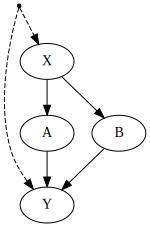

front-door sets: frozenset({frozenset({'A', 'B'})})


In [ ]:
ex4 = CausalGraphicalModel(
    nodes=['X','A','B','Y'],
    edges=[('X','A'),
           ('X','B'),
           ('A','Y'),
           ('B','Y')],
    latent_edges=[('X','Y')]
)

display(ex4.draw())
print("front-door sets: " + str(ex4.get_all_frontdoor_adjustment_sets('X','Y')))

---
## Exercise 5

Consider again the smoking example, for which we have the following data from an hypothetical experiment with 400 smokers and 400 non-smokers:

<img src='https://drive.google.com/uc?id=1RvqtRMF4auVECmSniLFm5yOCq3ykmT-0'>

Write a Python program implementing the front-door adjustment and compute the causal effect of smoking on lung cancer is $P(y | do(x))$.

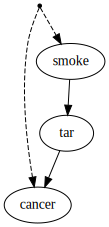

front-door sets: frozenset({frozenset({'tar'})})


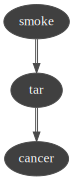

frontdoor_adj: P(cancer|do(smoking)): 0.2235
causal_model:  P(cancer|do(smoking)): 0.2235
frontdoor_adj: P(cancer|do(not_smoking)): 0.8264999999999999
causal_model:  P(cancer|do(not_smoking)): 0.8264999999999999


In [ ]:
# creating causal graphical model
smoking_cgm = CausalGraphicalModel(
    nodes=['smoke','tar','cancer'],
    edges=[('smoke','tar'),
           ('tar','cancer')],
    latent_edges=[('smoke','cancer')]
)

# printing causal graphical model and front door adjustment
display(smoking_cgm.draw())
print("front-door sets: " + str(smoking_cgm.get_all_frontdoor_adjustment_sets('smoke','cancer')))

# creating smoking bayesian netwotk
smoking_bn = gum.fastBN("smoke{Y|N}->tar{Y|N}->cancer{Y|N}")
smoking_bn.cpt("smoke")[:] = [0.5,0.5]
smoking_bn.cpt("tar")[{'smoke':'Y'}] = [0.95,0.05]
smoking_bn.cpt("tar")[{'smoke':'N'}] = [0.05,0.95]
smoking_bn.cpt("cancer")[{'tar':'Y'}] = [0.19,0.81]
smoking_bn.cpt("cancer")[{'tar':'N'}] = [0.86,0.14]

# printing smoking bayesian netwotk
smoking_cm = csl.CausalModel(smoking_bn)
cslnb.showCausalModel(smoking_cm)
gnb.flow.row(smoking_bn.cpt("smoke"),smoking_bn.cpt("tar"),smoking_bn.cpt("cancer"))

# calculating P(cancer | do(smoking)) with frontdoor adjustment
# P(cancer | do(smoking)) = sum_tar P(tar | smoking) sum_smoking P(cancer | tar, smoking)P(smoking)
P_cancer_do_smoking = 0
for t in ('Y','N'): # tar
    inner_sum = 0
    p_tar_given_smoking = smoking_bn.cpt("tar")[{'smoke': 0}][0 if t == 'Y' else 1]
    for s in ('Y','N'): # smoking
        p_cancer_given_tar_smoking = smoking_bn.cpt("cancer")[{'tar': t, 'smoke': s}][0] # Cancer=Y
        p_smoking = smoking_bn.cpt("smoke")[0 if s == 'Y' else 1]
        inner_sum += p_cancer_given_tar_smoking * p_smoking
    P_cancer_do_smoking += p_tar_given_smoking * inner_sum
print("frontdoor_adj: P(cancer|do(smoking)): " + str(P_cancer_do_smoking))

# calculating P(cancer | do(smoking)) with causal model
causal_effect_cancer_do_smoke = csl.causalImpact(smoking_cm, 'cancer', doing='smoke', values={'smoke':0})
print("causal_model:  P(cancer|do(smoking)): " + str(causal_effect_cancer_do_smoke[1][0]))

# calculating P(cancer | do(not smoking)) with frontdoor adjustment
# P(cancer | do(not smoking)) = sum_tar P(tar | not smoking) sum_smoking P(cancer | tar, smoking)P(smoking)
P_cancer_do_not_smoking = 0
for t in ('Y','N'): # tar
    inner_sum = 0
    p_tar_given_not_smoking = smoking_bn.cpt("tar")[{'smoke': 1}][0 if t == 'Y' else 1]
    for s in ('Y','N'): # smoking
        p_cancer_given_tar_smoking = smoking_bn.cpt("cancer")[{'tar': t, 'smoke': s}][0] # Cancer=Y
        p_smoking = smoking_bn.cpt("smoke")[0 if s == 'Y' else 1]
        inner_sum += p_cancer_given_tar_smoking * p_smoking
    P_cancer_do_not_smoking += p_tar_given_not_smoking * inner_sum
print("frontdoor_adj: P(cancer|do(not_smoking)): " + str(P_cancer_do_not_smoking))

# calculating P(cancer | do(not smoking)) with causal model
causal_effect_cancer_do_not_smoke = csl.causalImpact(smoking_cm, 'cancer', doing='smoke', values={'smoke':1})
print("causal_model:  P(cancer|do(not_smoking)): " + str(causal_effect_cancer_do_not_smoke[1][0]))
